In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from scipy.stats import gaussian_kde

In [2]:
## Output folder for figures
out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

In [3]:
## Load stability metrics
data = pd.read_csv('processed_data/crossyear_nnd_summary.csv', parse_dates=['date_now', 'date_prev'])
randomisations = pd.read_csv('processed_data/crossyear_nnd_with_randomisations.csv', parse_dates=['date_now', 'date_prev'])
pointwise = pd.read_csv('processed_data/crossyear_nnd_pointwise.csv', parse_dates=['date_curr', 'date_prev']).rename(columns={'date_curr': 'date_now'})
pointwise_randomisations = pd.read_csv('processed_data/crossyear_nnd_pointwise_randomisations.csv', parse_dates=['date_now', 'date_prev'])

## Factor ordering + labels
lek_labels = ['Tal Chhapar', 'Velavadar Lek 1', 'Velavadar Lek 2']

data['lek_id'] = (pd.Categorical(data['lek_id'],categories=lek_labels,ordered=True).rename_categories(lek_labels))
randomisations['lek_id'] = (pd.Categorical(randomisations['lek_id'],categories=lek_labels,ordered=True).rename_categories(lek_labels))
pointwise['lek_id'] = (pd.Categorical(pointwise['lek_id'],categories=lek_labels,ordered=True).rename_categories(lek_labels))
pointwise_randomisations['lek_id'] = (pd.Categorical(pointwise_randomisations['lek_id'],categories=lek_labels,ordered=True).rename_categories(lek_labels))

In [4]:
## Colour palettes
fill_cols = {'Tal Chhapar': '#B5542D', 'Velavadar Lek 1': '#1F6F8B', 'Velavadar Lek 2': '#3FA7A3'}
point_cols = {'Tal Chhapar': '#D97A52', 'Velavadar Lek 1': '#15556B', 'Velavadar Lek 2': '#2B7E7B'}

lek_labels = data['lek_id'].cat.categories.tolist()

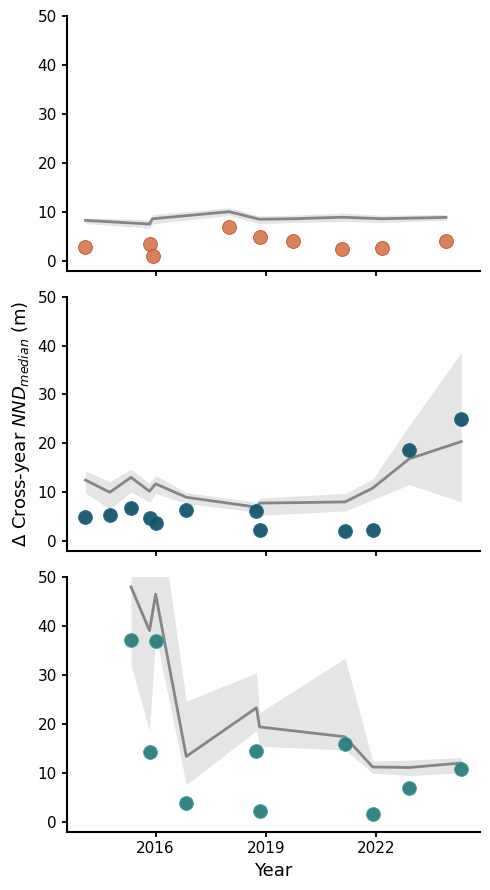

In [5]:
## Plot observed cross-year NND as deviation from the randomisation median
fig, axes = plt.subplots(3, 1, figsize=(5, 9), sharex=True)

for ax, lek in zip(axes, lek_labels):
    data_lek = data.loc[data['lek_id'] == lek].copy().sort_values('date_now')
    randomisations_lek = randomisations.loc[randomisations['lek_id'] == lek].copy()

    # Compute date specific null from the randomisations
    rand_band = randomisations_lek.groupby('date_now')['median_crossyear_nnd_transform_rand'].agg(low=lambda x: x.quantile(0.025),
                                                                                                  mid=lambda x: x.quantile(0.5),
                                                                                                  high=lambda x: x.quantile(0.975)).reset_index().sort_values('date_now')

    # Plot randomisations centred at zero
    ax.fill_between(rand_band['date_now'], rand_band['low'], rand_band['high'], color='#000000', alpha=0.1, linewidth=0, zorder=1)
    ax.plot(rand_band['date_now'], rand_band['mid'], color='grey', linewidth=2, alpha=0.95, zorder=2)
    
    ## Observed data relative to null median
    ax.scatter(data_lek['date_now'], data_lek['median_crossyear_nnd'], s=100, color=point_cols[lek], edgecolor=fill_cols[lek], linewidth=0.6, alpha=0.95, zorder=3)

    ax.set_ylim(-2,40)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.xaxis.set_major_locator(mdates.YearLocator(3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_yticks([0,10,20,30,40,50])
    ax.tick_params(axis='both', labelsize=11, width=1.3)

axes[1].set_ylabel('$\Delta$ Cross-year $NND_{median}$ (m)', fontsize=13)
axes[-1].set_xlabel('Year', fontsize=13)

plt.tight_layout()
# plt.savefig(out_dir/'plot_external_memory.png', dpi=300, bbox_inches='tight')

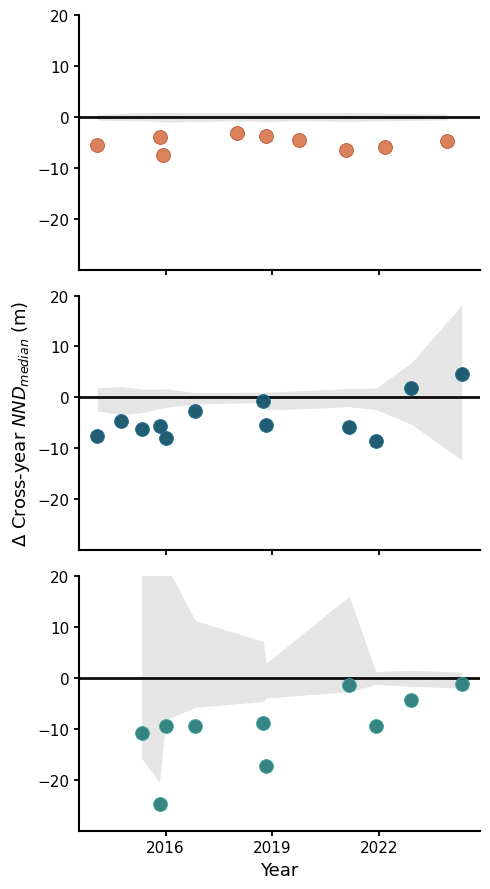

In [6]:
## Plot observed cross-year NND as deviation from the transformation median
fig, axes = plt.subplots(3, 1, figsize=(5, 9), sharex=True)

for ax, lek in zip(axes, lek_labels):
    data_lek = data.loc[data['lek_id'] == lek].copy().sort_values('date_now')
    randomisations_lek = randomisations.loc[randomisations['lek_id'] == lek].copy()

    # Compute date specific null from the randomisations
    rand_band = randomisations_lek.groupby('date_now')['median_crossyear_nnd_transform_rand'].agg(low=lambda x: x.quantile(0.025),
                                                                                                  mid=lambda x: x.quantile(0.5),
                                                                                                  high=lambda x: x.quantile(0.975)).reset_index().sort_values('date_now')

    # Express everything relative to the null median
    rand_band['low_dev'] = rand_band['low'] - rand_band['mid']
    rand_band['high_dev'] = rand_band['high'] - rand_band['mid']

    data_dev = data_lek.merge(rand_band[['date_now', 'mid']], on='date_now', how='left').assign(obs_dev=lambda df: df['median_crossyear_nnd'] - df['mid'])

    # Plot randomisations centred at zero
    ax.fill_between(rand_band['date_now'], rand_band['low_dev'], rand_band['high_dev'], color='#000000', alpha=0.1, linewidth=0, zorder=1)
    ax.axhline(0, color='black', linewidth=2, alpha=0.95, zorder=2)

    ## Observed data relative to null median
    ax.scatter(data_dev['date_now'], data_dev['obs_dev'], s=100, color=point_cols[lek], edgecolor=fill_cols[lek], linewidth=0.6, alpha=0.95, zorder=3)

    ax.set_ylim(-30,20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.xaxis.set_major_locator(mdates.YearLocator(3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_yticks([-20,-10,0,10,20])
    ax.tick_params(axis='both', labelsize=11, width=1.3)

axes[1].set_ylabel('$\Delta$ Cross-year $NND_{median}$ (m)', fontsize=13)
axes[-1].set_xlabel('Year', fontsize=13)

plt.tight_layout()
plt.savefig(out_dir/'external_memory_over_time.png', dpi=300, bbox_inches='tight')

In [9]:
def log_kde_on_original_scale(y, xs, bw_method=0.3, eps=1e-6):
    y = y[np.isfinite(y)]
    y = y[y > 0]

    z = np.log(y + eps)
    kde = gaussian_kde(z, bw_method=bw_method)

    xs_pos = np.maximum(xs, eps)
    density = kde(np.log(xs_pos + eps)) / (xs_pos + eps)

    return density

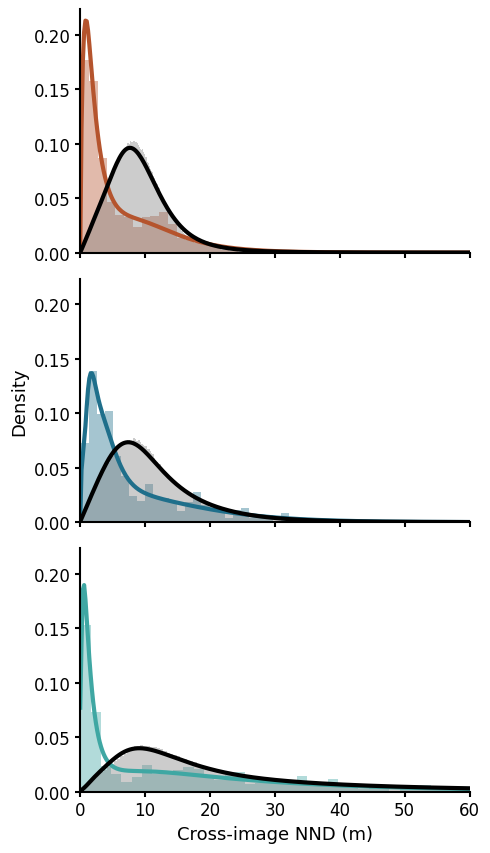

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(5, 9), sharex=True, sharey=True)
bin_dict = {'Velavadar Lek 1': 30, 'Velavadar Lek 2': 60, 'Tal Chhapar': 20}
for ax, lek in zip(axes, lek_labels):
    obs = pointwise.loc[pointwise['lek_id'] == lek, 'nnd_to_prev'].to_numpy()
    rand = pointwise_randomisations.loc[pointwise_randomisations['lek_id'] == lek, 'nnd_to_prev'].to_numpy()

    # Plot data and randomisation
    ax.hist(obs, bins=bin_dict[lek], density=True, color=fill_cols[lek], alpha=0.4)
    ax.hist(rand, bins='fd', density=True, color='grey',alpha=0.4)

    # Add KDEs for data and randomisation   
    xs = np.linspace(0.01, 60, 300)

    ys_obs = log_kde_on_original_scale(obs, xs)
    ys_rand = log_kde_on_original_scale(rand, xs)

    ax.plot(xs, ys_obs, color=fill_cols[lek], linewidth=3)
    ax.plot(xs, ys_rand, color='black', linewidth=3)

    ax.set_xlim(0,60)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

axes[1].set_ylabel('Density', fontsize=13)
axes[-1].set_xlabel('Cross-image NND (m)', fontsize=13)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(out_dir/'external_memory_distribution.png', dpi=300, bbox_inches='tight')

Text(0, 0.5, 'Cross-year NND (m)')

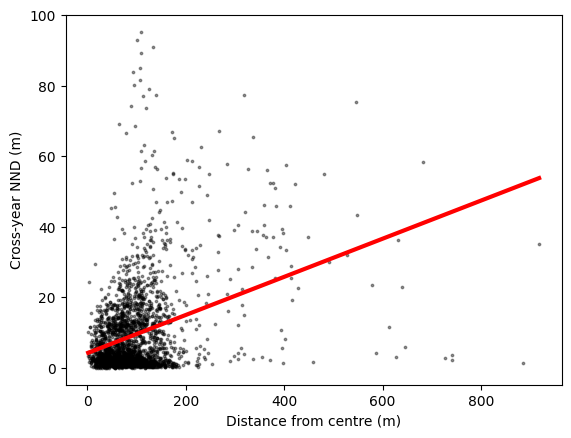

In [16]:
from scipy.stats import linregress
import numpy as np

x = pointwise['dist_from_centre'].to_numpy()
y = pointwise['nnd_to_prev'].to_numpy()

plt.scatter(x, y, c='black', s=3, alpha=0.4)

# Fit regression
slope, intercept, r, p, se = linregress(x, y)

# Plot line
xs = np.linspace(x.min(), x.max(), 200)
ys = intercept + slope * xs

plt.plot(xs, ys, color='red', linewidth=3)

plt.xlabel('Distance from centre (m)')
plt.ylabel('Cross-year NND (m)')

Text(0, 0.5, 'Cross-year NND (m)')

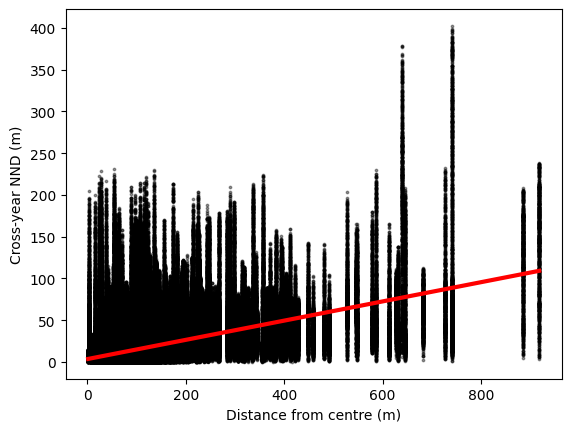

In [17]:
from scipy.stats import linregress
import numpy as np

x = pointwise_randomisations['dist_from_centre'].to_numpy()
y = pointwise_randomisations['nnd_to_prev'].to_numpy()

plt.scatter(x, y, c='black', s=3, alpha=0.4)

# Fit regression
slope, intercept, r, p, se = linregress(x, y)

# Plot line
xs = np.linspace(x.min(), x.max(), 200)
ys = intercept + slope * xs

plt.plot(xs, ys, color='red', linewidth=3)

plt.xlabel('Distance from centre (m)')
plt.ylabel('Cross-year NND (m)')